In [1]:
import pandas as pd

data_path = "../data/raw/yield_df.csv"

df = pd.read_csv(data_path)

print(df.shape)
df.head()
df.tail()

(28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
28237,28237,Zimbabwe,"Rice, paddy",2013,22581,657.0,2550.07,19.76
28238,28238,Zimbabwe,Sorghum,2013,3066,657.0,2550.07,19.76
28239,28239,Zimbabwe,Soybeans,2013,13142,657.0,2550.07,19.76
28240,28240,Zimbabwe,Sweet potatoes,2013,22222,657.0,2550.07,19.76
28241,28241,Zimbabwe,Wheat,2013,22888,657.0,2550.07,19.76


**Basic information about the dataset**

In [2]:
# Basic information about the dataset

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (28242, 8)

Column names:
['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

Data types:
Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object


**Display basic statistical information**

In [3]:
# Display basic statistical information

df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


**Check missing values**

In [4]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


**Check duplicate rows**

In [5]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Remove duplicates if any exist**
   

In [6]:
# Remove duplicates if any exist

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (28242, 8)


**Remove the unnecessary column**

Unnamed: 0   
This is simply an exported index and should not be used as a machine-learning feature.

In [7]:
df = df.drop(columns=["Unnamed: 0"])

print(df.columns.tolist())

['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


**Rename columns**

#The original names aren't very convenient for ML work.

In [8]:
df = df.rename(columns={
    "Area": "Country",
    "Item": "Crop",
    "hg/ha_yield": "Yield_hg_ha",
    "average_rain_fall_mm_per_year": "Rainfall_mm_per_year",
    "pesticides_tonnes": "Pesticides_tonnes",
    "avg_temp": "Avg_Temperature_C"
})

df.head()

,Country,Crop,Year,Yield_hg_ha,Rainfall_mm_per_year,Pesticides_tonnes,Avg_Temperature_C
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


**Understand the categorical variables**

In [9]:
print("Number of countries:", df["Country"].nunique())
print("Number of crops:", df["Crop"].nunique())

Number of countries: 101
Number of crops: 10


#This is important because Country and Crop are categorical variables. Later we'll convert them into numerical representations using encoding.

In [10]:
print("\nCountries:")
print(df["Country"].unique())


Countries:
['Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Belarus' 'Belgium'
 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Canada' 'Central African Republic' 'Chile' 'Colombia' 'Croatia'
 'Denmark' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Eritrea'
 'Estonia' 'Finland' 'France' 'Germany' 'Ghana' 'Greece' 'Guatemala'
 'Guinea' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'India' 'Indonesia' 'Iraq'
 'Ireland' 'Italy' 'Jamaica' 'Japan' 'Kazakhstan' 'Kenya' 'Latvia'
 'Lebanon' 'Lesotho' 'Libya' 'Lithuania' 'Madagascar' 'Malawi' 'Malaysia'
 'Mali' 'Mauritania' 'Mauritius' 'Mexico' 'Montenegro' 'Morocco'
 'Mozambique' 'Namibia' 'Nepal' 'Netherlands' 'New Zealand' 'Nicaragua'
 'Niger' 'Norway' 'Pakistan' 'Papua New Guinea' 'Peru' 'Poland' 'Portugal'
 'Qatar' 'Romania' 'Rwanda' 'Saudi Arabia' 'Senegal' 'Slovenia'
 'South Africa' 'Spain' 'Sri Lanka' 'Sudan' 'Suriname' 'Sweden'
 'Switzerland'

In [11]:
print("\nCrops:")
print(df["Crop"].unique())


Crops:
['Maize' 'Potatoes' 'Rice, paddy' 'Sorghum' 'Soybeans' 'Wheat' 'Cassava'
 'Sweet potatoes' 'Plantains and others' 'Yams']


**Look at the target variable**

#Our target is:

Yield_hg_ha

In [12]:
print(df["Yield_hg_ha"].describe())

count     28242.000000
mean      77053.332094
std       84956.612897
min          50.000000
25%       19919.250000
50%       38295.000000
75%      104676.750000
max      501412.000000
Name: Yield_hg_ha, dtype: float64


**This gives us our first important visualization.**

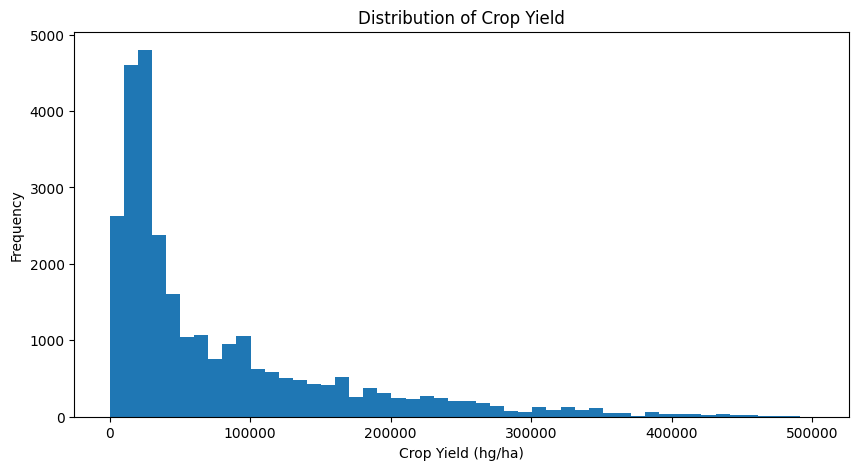

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["Yield_hg_ha"], bins=50)

plt.xlabel("Crop Yield (hg/ha)")
plt.ylabel("Frequency")
plt.title("Distribution of Crop Yield")

plt.show()